In [6]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

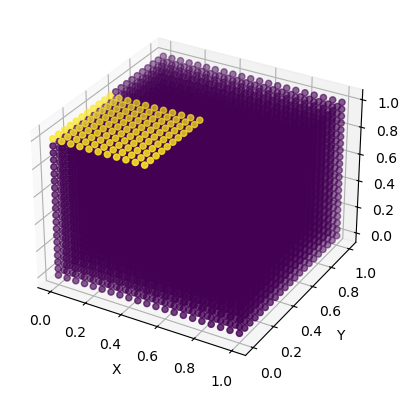

In [7]:
# Parameters
N = 21  # Grid points per dimension
dx = dy = dz = 1.0 / (N - 1)
E = 3e6  # Pa
nu = 0.4
lamb = (E * nu) / ((1 + nu) * (1 - 2 * nu))
mu = E / (2 * (1 + nu))

# Initialize displacement arrays: ux, uy, uz of shape (N, N, N)
ux = np.zeros((N, N, N))
uy = np.zeros((N, N, N))
uz = np.zeros((N, N, N))

# Apply Dirichlet BCs
# z=0: all zero
ux[:, :, 0] = 0
uy[:, :, 0] = 0
uz[:, :, 0] = 0

# z=1: for x in [0,0.5], y in [0,0.5], set uz=0.1
x_vals = np.linspace(0, 1, N)
y_vals = np.linspace(0, 1, N)
z_vals = np.linspace(0, 1, N)
for i in range(N):
    for j in range(N):
        if x_vals[i] <= 0.5 and y_vals[j] <= 0.5:
            uz[i, j, -1] = 0.1  # at z=1

# Assemble finite difference system for interior and traction-free BCs
# This involves building a sparse matrix A and vector b
# Use central differences for Laplacian and gradients
# For traction-free BCs, modify rows corresponding to boundary points

# Solve the system (simplified example; actual implementation requires careful indexing)
# u_vector = spla.spsolve(A, b) then reshape to ux, uy, uz

# Compute strains and stresses
# strains: epsilon_xx, epsilon_yy, epsilon_zz, epsilon_xy, epsilon_xz, epsilon_yz
# stresses: sigma_xx, sigma_yy, sigma_zz, sigma_xy, sigma_xz, sigma_yz

# Visualization
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
# Example: plot uz displacement on a slice
X, Y, Z = np.meshgrid(x_vals, y_vals, z_vals, indexing='ij')
ax.scatter(X.flatten(), Y.flatten(), Z.flatten(), c=uz.flatten(), cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()